## Region mask example from SILO
The example will compute the mean annual rainfall for Queensland. To process data for a specific region, you must provide a NetCDF mask file with the same geometry as the data file(s). If you already have a mask file in another format, you may be able to convert it to NetCDF format using GDAL

In [1]:
import numpy
import netCDF4

# Define the full path to the regional mask file
mask_file_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_qld.nc"

# Load the regional mask
with netCDF4.Dataset(mask_file_path, 'r') as mask_dataset:
    mask_data = mask_dataset.variables['mask'][:]

# Initialise the results list
results = []

# Define the directory where rainfall files are stored
rainfall_data_dir = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/"

# Loop over years
for year in range(2011, 2024):
    # Construct the full file path for the yearly NetCDF file
    rainfall_file_path = f"{rainfall_data_dir}{year}.monthly_rain.nc"

    try:
        # Load the monthly rainfall data for all months in the year
        with netCDF4.Dataset(rainfall_file_path, 'r') as dataset:
            data = dataset.variables['monthly_rain'][:]
            # Apply regional mask to the data
            data.mask = mask_data.mask
            # Calculate the annual regional average rainfall
            # by computing the average across all months
            # and all grid points within the mask
            average = numpy.mean(data)
        
        # Append result to the list
        results.append(average)

    except FileNotFoundError:
        print(f"Warning: File not found for year {year}: {rainfall_file_path}")

# Print results
print(results)

[67.5963968554177, 54.94855719324551, 39.945897803792334, 45.439337170310594, 39.29646207316331, 51.55657449225251, 44.67358817167473, 42.2417324278935, 39.392497785313935, 47.643981896640625, 55.76997986402093, 64.52434673557998, 57.60940168153073]


## 1. Creating the Mask File
Here's how to create a NetCDF mask file from your SA2 cropping region shapefile:

In [2]:
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import numpy as np
import netCDF4

# Paths
shapefile_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/Australia_SA2_Wheat_clipped/Australia_SA2_Wheat_clipped.shp"
rainfall_sample_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2011.monthly_rain.nc"
mask_output_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_sa2.nc"

# Load the SA2 cropping region shapefile
gdf = gpd.read_file(shapefile_path)

# Open a sample rainfall dataset to get the spatial reference
with xr.open_dataset(rainfall_sample_file) as ds:
    lat = ds["lat"].values  # Extract latitude grid
    lon = ds["lon"].values  # Extract longitude grid
    grid_shape = (len(lat), len(lon))

# Create an empty mask array for all SA2 regions
mask = np.zeros((len(gdf), grid_shape[0], grid_shape[1]), dtype=np.uint8)

# Generate affine transform for rasterization
transform = rasterio.transform.from_bounds(lon.min(), lat.min(), lon.max(), lat.max(), grid_shape[1], grid_shape[0])

# Loop through each SA2 region and rasterize its geometry separately
for i, row in gdf.iterrows():
    geometry = row.geometry

    # Rasterize current SA2 region into the corresponding mask layer
    mask[i, :, :] = rasterize(
        [(geometry, 1)],  # Assign a value of 1 to the polygon area
        out_shape=grid_shape,
        transform=transform,
        fill=0,  # Background remains 0
        all_touched=False,  # Avoid overlapping regions
        dtype=np.uint8
    )

# Save the mask as a NetCDF file
with netCDF4.Dataset(mask_output_path, "w", format="NETCDF4") as ncfile:
    ncfile.createDimension("sa2", len(gdf))
    ncfile.createDimension("lat", len(lat))
    ncfile.createDimension("lon", len(lon))

    # Create NetCDF variables
    sa2_ids = ncfile.createVariable("sa2_id", "i4", ("sa2",))
    latitudes = ncfile.createVariable("lat", "f4", ("lat",))
    longitudes = ncfile.createVariable("lon", "f4", ("lon",))
    mask_var = ncfile.createVariable("mask", "u1", ("sa2", "lat", "lon"))

    # Assign values
    sa2_ids[:] = np.arange(len(gdf))  # Assign IDs
    latitudes[:] = lat
    longitudes[:] = lon
    mask_var[:, :, :] = mask  # Assign mask data

print(f"✅ Fixed mask file saved to: {mask_output_path}")


✅ Fixed mask file saved to: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_sa2.nc


# To calculate the mean rainfall for each region and display with Year, SA2 Name, and average rainfall, you would need to modify the code as follows:


In [4]:

# To calculate the mean rainfall for each region and display with Year, SA2 Name, and average rainfall, you would need to modify the code as follows:
import numpy as np
import netCDF4
import pandas as pd
import geopandas as gpd

# Paths
mask_file_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_sa2.nc"
rainfall_data_dir = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/"
sa2_names_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/Australia_SA2_Wheat_clipped/Australia_SA2_Wheat_clipped.shp"

# Load SA2 names from the shapefile
gdf = gpd.read_file(sa2_names_file)
sa2_names = list(gdf["SA2_NAME16"])  # Adjust column name if needed

# Load the mask file
with netCDF4.Dataset(mask_file_path, "r") as mask_dataset:
    mask_data = mask_dataset.variables["mask"][:]  # Expected shape: (regions, lat, lon)

# Validate shape consistency
print(f"Mask shape: {mask_data.shape} (Regions, Lat, Lon)")

if mask_data.shape[0] != len(sa2_names):
    raise ValueError("Mismatch between number of SA2 mask regions and SA2 names.")

# List to store results
results = []

# Loop over years
for year in range(2011, 2024):
    rainfall_file_path = f"{rainfall_data_dir}{year}.monthly_rain.nc"

    try:
        with netCDF4.Dataset(rainfall_file_path, "r") as dataset:
            data = dataset.variables["monthly_rain"][:]  # Shape: (months, lat, lon)
            lat = dataset.variables["lat"][:]
            lon = dataset.variables["lon"][:]

            # Compute annual mean rainfall (averaging over months)
            annual_rainfall = np.nanmean(data, axis=0)  # Shape: (lat, lon)
            print(f"Processing {year}, Annual Rainfall Shape: {annual_rainfall.shape}")

            # Compute mean rainfall per SA2 region
            for region in range(mask_data.shape[0]):
                region_mask = mask_data[region, :, :].astype(bool)  # Ensure boolean mask

                if np.sum(region_mask) == 0:
                    print(f"Warning: No valid grid points for {sa2_names[region]} in year {year}")
                    regional_mean = np.nan  # If no valid pixels, return NaN
                else:
                    masked_values = np.array(annual_rainfall[region_mask], dtype=np.float64)  # Ensure writable
                    regional_mean = np.nanmean(masked_values)  # Compute mean

                results.append({"Year": year, "SA2_Name": sa2_names[region], "Mean_Rainfall": regional_mean})

    except FileNotFoundError:
        print(f"Warning: File not found for year {year}: {rainfall_file_path}")

# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Save results to CSV
df_results.to_csv("SA2_annual_rainfall_fixed.csv", index=False)
print("Results saved to SA2_annual_rainfall_fixed.csv")

# Display results
print(df_results.tail())  # Show the first few rows



     
           




Mask shape: (190, 681, 841) (Regions, Lat, Lon)
Processing 2011, Annual Rainfall Shape: (681, 841)


/tmp/ipykernel_30045/2207541026.py:52: RuntimeWarning: Mean of empty slice
  regional_mean = np.nanmean(masked_values)  # Compute mean


Processing 2012, Annual Rainfall Shape: (681, 841)
Processing 2013, Annual Rainfall Shape: (681, 841)
Processing 2014, Annual Rainfall Shape: (681, 841)
Processing 2015, Annual Rainfall Shape: (681, 841)
Processing 2016, Annual Rainfall Shape: (681, 841)
Processing 2017, Annual Rainfall Shape: (681, 841)
Processing 2018, Annual Rainfall Shape: (681, 841)
Processing 2019, Annual Rainfall Shape: (681, 841)
Processing 2020, Annual Rainfall Shape: (681, 841)
Processing 2021, Annual Rainfall Shape: (681, 841)
Processing 2022, Annual Rainfall Shape: (681, 841)
Processing 2023, Annual Rainfall Shape: (681, 841)
Results saved to SA2_annual_rainfall_fixed.csv
      Year              SA2_Name  Mean_Rainfall
2465  2023           The Coorong     101.714379
2466  2023        Renmark Region      62.534226
2467  2023  Murray Bridge Region     112.330144
2468  2023    Strathalbyn Region     122.714167
2469  2023              Waikerie      83.270728


In [9]:
print(f"Mask shape: {mask_data.shape}")  # Expected: (regions, lat, lon)
with netCDF4.Dataset(rainfall_file_path, "r") as dataset:
    print(f"Rainfall data shape: {dataset.variables['monthly_rain'].shape}")  # Expected: (months, lat, lon)


Mask shape: (190, 681, 841)
Rainfall data shape: (12, 681, 841)


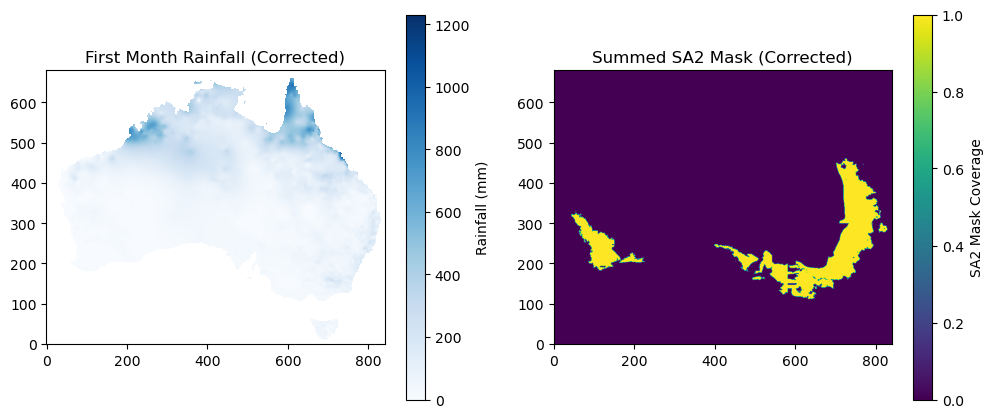

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# First Month Rainfall (Corrected)
plt.subplot(1, 2, 1)
plt.imshow(first_month_rainfall, cmap="Blues", origin="lower")  # Fix orientation
plt.colorbar(label="Rainfall (mm)")
plt.title("First Month Rainfall (Corrected)")

# SA2 Mask (Flip Manually to Match Orientation)
plt.subplot(1, 2, 2)
plt.imshow(np.flipud(np.sum(mask_data, axis=0)), cmap="viridis", origin="lower")  # Flip mask
plt.colorbar(label="SA2 Mask Coverage")
plt.title("Summed SA2 Mask (Corrected)")

plt.show()







In [13]:
with netCDF4.Dataset(rainfall_file_path, "r") as dataset:
    rain_lat = dataset.variables["lat"][:]

with netCDF4.Dataset(mask_file_path, "r") as dataset:
    mask_lat = dataset.variables["lat"][:]

print(f"Rainfall latitude range: {rain_lat[0]} to {rain_lat[-1]}")
print(f"Mask latitude range: {mask_lat[0]} to {mask_lat[-1]}")



Rainfall latitude range: -44.0 to -10.0
Mask latitude range: -44.0 to -10.0
